## IMPORTS

In [3]:
# import numpy as np
# import pandas as pd
# import pickle
# import faiss
#
# from sklearn.decomposition import PCA
# from sklearn.cluster import KMeans
# from sklearn.preprocessing import normalize
# from sklearn.neighbors import NearestNeighbors
#
# from scipy.cluster.hierarchy import linkage, dendrogram
# import matplotlib.pyplot as plt
#
# import plotly.express as px
# import plotly.io as pio
# pio.renderers.default = "browser"
# # RUTA DE ARCHIVOS
# base_path = r"C:\Users\rmont\Downloads\proyecto3_chatbot_musical\proyecto3_chatbot_musical\data\embeddings_cache"
#
# # CARGA DE DATOS
# with open(f"{base_path}\\chunks_parrafos.pkl", "rb") as f:
#     chunks = pickle.load(f)
#
# embeddings = np.load(f"{base_path}\\embeddings_parrafos.npy")
# index = faiss.read_index(f"{base_path}\\indice_parrafos.faiss")
#
# print("Datos cargados")
# print("Chunks:", len(chunks))
# print("Embeddings shape:", embeddings.shape)
# print("FAISS index:", index.ntotal)


Datos cargados
Chunks: 12229
Embeddings shape: (12229, 768)
FAISS index: 12229


## EDA EMBEDDINGS

✅ Datos cargados
Chunks: 12229
Embeddings: (12229, 768)
FAISS: 12229


Clusters: [0 1 2 3]


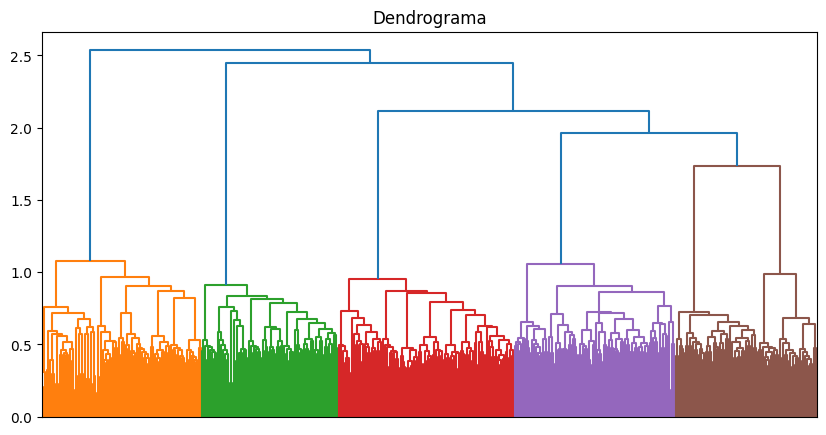


🎤 Artistas dominantes por cluster

Cluster 0
    cluster              artista  count
110       0              xandria     23
60        0              kamelot     18
104       0  visions of atlantis     16
64        0         leaves' eyes     15
56        0             immortal     12

Cluster 1
    cluster     artista  count
130       1  kanye west     21
125       1      eminem     21
124       1       drake     20
127       1      future     18
137       1    lil baby     15

Cluster 2
    cluster          artista  count
174       2  cannibal corpse     23
170       2        bloodbath     18
200       2     fear factory     17
257       2           slayer     16
188       2          deicide     15

Cluster 3
    cluster         artista  count
291       3  britney spears     22
348       3         madonna     18
339       3            korn     17
331       3   justin bieber     16
354       3     miley cyrus     16



✅ EDA COMPLETO
📁 Gráficos en: graficos


In [1]:
import sys
import os

project_root = r"C:\Users\rmont\Downloads\proyecto3_chatbot_musical\proyecto3_chatbot_musical"

sys.path.append(project_root)
from src.eda_embeddings import EmbeddingsEDA

base_path = r"C:\Users\rmont\Downloads\proyecto3_chatbot_musical\proyecto3_chatbot_musical\data\embeddings_cache"

eda = EmbeddingsEDA(base_path, show=True, save=True)

eda.run_all()

In [ ]:
#pruebas

In [4]:
print("Shape:", embeddings.shape)
norms = np.linalg.norm(embeddings, axis=1)

fig = px.histogram(
    norms,
    nbins=50,
    title="Distribucion de normas de embeddings",
    template="plotly_dark"
)
fig.show()

Shape: (12229, 768)


## DISTRIBUCION DIMENSIONES

In [5]:
df_dims = pd.DataFrame(embeddings[:, :20])

fig = px.box(
    df_dims,
    title="Distribucion de primeras 20 dimensiones",
    template="plotly_dark"
)
fig.show()

## PCA CORRELACION

In [7]:
pca_full = PCA(n_components=10)
pca_data = pca_full.fit_transform(embeddings)

df_pca = pd.DataFrame(pca_data)

fig = px.imshow(
    df_pca.corr(),
    text_auto=True,
    color_continuous_scale="RdBu",
    title="Correlacion entre componentes PCA",
    template="plotly_dark"
)

fig.update_layout(width=700, height=700)
fig.show()


## DENSIDAD SEMANTICA

In [ ]:
nbrs = NearestNeighbors(n_neighbors=5).fit(embeddings)
distances, _ = nbrs.kneighbors(embeddings)

avg_density = distances.mean(axis=1)

fig = px.histogram(
    avg_density,
    nbins=50,
    title="Densidad semantica",
    template="plotly_dark"
)
fig.show()


## METODO DEL CODO

In [ ]:
inertias = []
K_range = range(1, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings)
    inertias.append(kmeans.inertia_)

fig = px.line(
    x=list(K_range),
    y=inertias,
    markers=True,
    title="Metodo del codo",
    template="plotly_dark"
)

fig.update_layout(
    xaxis_title="Numero de clusters",
    yaxis_title="Inercia"
)

fig.show()
# CLUSTERING
embeddings_norm = normalize(embeddings)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(embeddings_norm)

print("Clusters unicos:", np.unique(labels))


## DENDROGRAMA

In [ ]:
sample_small = embeddings[:500]

Z = linkage(sample_small, method='ward')

plt.figure(figsize=(10,5))
dendrogram(Z, no_labels=True)
plt.title("Dendrograma sample")
plt.show()


## MAPA SEMANTICO

In [ ]:
# SAMPLE
sample_size = 2000
sample_idx = np.random.choice(len(embeddings_norm), sample_size, replace=False)

sample_embeddings = embeddings_norm[sample_idx]
sample_labels = labels[sample_idx]

# EXTRAER DATOS
sample_titles = [chunks[i][0] for i in sample_idx]
sample_artists = [chunks[i][1] for i in sample_idx]
sample_lyrics = [chunks[i][2] for i in sample_idx]

# PCA VISUAL
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(sample_embeddings)

# DATAFRAME
df = pd.DataFrame({
    "x": emb_2d[:, 0],
    "y": emb_2d[:, 1],
    "cluster": sample_labels.astype(str),
    "titulo": sample_titles,
    "artista": sample_artists,
    "letra": sample_lyrics
})

df["letra_corta"] = df["letra"].str[:120] + "..."

# MAPA SEMANTICO
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="cluster",
    hover_data={
        "titulo": True,
        "artista": True,
        "letra_corta": True,
        "x": False,
        "y": False
    },
    title="Mapa semantico de canciones",
    template="plotly_dark"
)

fig.update_traces(marker=dict(size=6, opacity=0.7))
fig.show()

# DISTRIBUCION CLUSTERS
cluster_counts = df["cluster"].value_counts().reset_index()
cluster_counts.columns = ["cluster", "count"]

fig_bar = px.bar(
    cluster_counts,
    x="cluster",
    y="count",
    color="cluster",
    title="Distribucion por cluster",
    template="plotly_dark"
)

fig_bar.show()


## ARTISTAS POR CLUSTER

In [ ]:
df_group = df.groupby(["cluster", "artista"]).size().reset_index(name="count")

print("Artistas dominantes por cluster")

for c in sorted(df["cluster"].unique()):
    print(f"\nCluster {c}")
    print(
        df_group[df_group["cluster"] == c]
        .sort_values("count", ascending=False)
        .head(5)
    )

## METADATA ANALISIS

In [ ]:
df_meta = pd.DataFrame({
    "titulo": [x[0] for x in chunks],
    "artista": [x[1] for x in chunks],
})

fig = px.bar(
    df_meta["artista"].value_counts().head(20),
    title="Top artistas",
    template="plotly_dark"
)
fig.show()

df_meta["longitud"] = [len(x[2].split()) for x in chunks]

fig = px.histogram(
    df_meta,
    x="longitud",
    nbins=50,
    title="Longitud de letras",
    template="plotly_dark"
)
fig.show()